In [1]:
# ===============================================================
# CELL 1: Install dependencies
# ===============================================================
!pip install PyWavelets seaborn --quiet


In [2]:
# ===============================================================
# CELL 2: Upload Excel file (Log-Transformed-Data.xlsx)
# ===============================================================
from google.colab import files

uploaded = files.upload()   # choose Log-Transformed-Data.xlsx
DATA_FILE = list(uploaded.keys())[0]
print("Using data file:", DATA_FILE)

Saving Yuan Reprecing.xlsx to Yuan Reprecing.xlsx
Using data file: Yuan Reprecing.xlsx


In [3]:
# ===============================================================
# CELL 3: Imports, settings, data load
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

plt.style.use("seaborn-v0_8-darkgrid")

DATE_COL = "Dates"
SERIES_COLS = ["US", "UK", "Germany", "France", "Japan", "Brazil", "China", "Gold", "Silver", "Copper", "Bitcoin"]

PAIR_LIST = [
    ("US", "Bitcoin"),
    ("US", "Gold"),
    ("US", "Silver"),
    ("US", "Copper"),
    ("UK", "Bitcoin"),
    ("UK", "Gold"),
    ("UK", "Silver"),
    ("UK", "Copper"),
    ("Germany", "Bitcoin"),
    ("Germany", "Gold"),
    ("Germany", "Silver"),
    ("Germany", "Copper"),
    ("France", "Bitcoin"),
    ("France", "Gold"),
    ("France", "Silver"),
    ("France", "Copper"),
    ("Japan", "Bitcoin"),
    ("Japan", "Gold"),
    ("Japan", "Silver"),
    ("Japan", "Copper"),
    ("Brazil", "Bitcoin"),
    ("Brazil", "Gold"),
    ("Brazil", "Silver"),
    ("Brazil", "Copper"),
    ("China", "Bitcoin"),
    ("China", "Gold"),
    ("China", "Silver"),
    ("China", "Copper"),
]

dt = 1.0  # daily

# Load Excel
df_raw = pd.read_excel(DATA_FILE)
df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], dayfirst=True, errors="coerce")
df_raw = df_raw.sort_values(DATE_COL).set_index(DATE_COL)

df = df_raw[SERIES_COLS].copy()
df = df.dropna(how="any")

# Use log-levels from file, but compute log-returns for hedge ratios
df_ret = df.diff().dropna()

print("Data shape (common intersection):", df.shape)
display(df.head())

Data shape (common intersection): (65, 11)


,US,UK,Germany,France,Japan,Brazil,China,Gold,Silver,Copper,Bitcoin
Dates,,,,,,,,,,,
2015-08-03,0.003454,0.003454,0.026661,-0.003486,0.0,0.022946,0.008262,-0.008256,0.011608,-0.001821,-0.002814
2015-08-04,0.003865,0.003865,0.030917,0.019156,0.0,0.010880,0.009882,0.000837,-0.012983,0.003400,0.004989
2015-08-05,0.003955,0.003955,-0.047030,0.002766,0.0,0.004824,0.001607,-0.002458,-0.001376,-0.011684,-0.008730
2015-08-06,0.000000,0.000000,0.011860,0.002374,0.0,0.055589,-0.011478,0.004157,0.004809,0.001546,-0.014315
2015-08-07,0.000000,0.000000,-0.011860,-0.004872,0.0,0.014436,0.000000,0.004213,0.010907,-0.002514,0.003044


In [4]:
# ===============================================================
# CELL 4: Helper functions for MODWT-style multiscale hedge ratios
# ===============================================================
def modwt_like_decomposition(series, wavelet="db4", level=None):
    """
    Use pywt.wavedec as a MODWT-like multiscale decomposition:
    - Returns detail coefficients D1..D_level as a dict(level -> np.array).
    """
    y = series.values
    max_level = pywt.dwt_max_level(len(y), pywt.Wavelet(wavelet).dec_len)
    if level is None or level > max_level:
        level = max_level

    coeffs = pywt.wavedec(y, wavelet, level=level, mode="periodization")
    # coeffs[0] is approximation at highest level, coeffs[1:] are details.
    details = {}
    for j in range(1, level + 1):
        details[j] = coeffs[j]
    return details, level


def multiscale_hedge_ratios(x_ret, y_ret, wavelet="db4", level=None):
    """
    Compute multiscale hedge ratios h_j for levels j using detail coefficients:
        h_j = cov(Dx_j, Dy_j) / var(Dy_j)

    x_ret: hedge asset returns
    y_ret: Bitcoin returns
    """
    x_ret, y_ret = x_ret.align(y_ret, join="inner")

    Dx_dict, Lx = modwt_like_decomposition(x_ret, wavelet=wavelet, level=level)
    Dy_dict, Ly = modwt_like_decomposition(y_ret, wavelet=wavelet, level=level)
    L = min(Lx, Ly)

    h_levels = {}
    for j in range(1, L + 1):
        Dx = Dx_dict[j]
        Dy = Dy_dict[j]
        cov_xy = np.nanmean(Dx * Dy)
        var_y = np.nanmean(Dy ** 2)
        h_j = cov_xy / (var_y + 1e-12)
        h_levels[j] = h_j
    return h_levels, L


def level_to_period_range(j, dt=1.0):
    """
    Approximate period (in days) corresponding to wavelet level j for DWT/MODWT:
      Level j ≈ periods in [2^(j-1)*dt, 2^j * dt] days. [web:23][web:53]
    """
    low = (2 ** (j - 1)) * dt
    high = (2 ** j) * dt
    return low, high

In [5]:
# ===============================================================
# CELL 5: Map levels to target horizon bands and compute band hedge ratios
# ===============================================================
# Target horizon bands (in days)
bands = [
    (2, 4),
    (4, 8),
    (8, 16),
    (16, 32),
    (32, 64),
    (64, 128),
]

def assign_levels_to_bands(max_level, dt=1.0):
    """
    For each level j, compute its period range and assign it to closest band(s).
    Returns:
        band_levels: dict[band] -> list of levels j that fall substantially in that band.
    """
    band_levels = {b: [] for b in bands}
    for j in range(1, max_level + 1):
        low_j, high_j = level_to_period_range(j, dt=dt)
        for b in bands:
            low_b, high_b = b
            # simple overlap rule: if ranges intersect, assign level j to band b
            if (low_j < high_b) and (high_j > low_b):
                band_levels[b].append(j)
    return band_levels


def band_averaged_hedge_ratios(h_levels, band_levels):
    """
    For each band, average h_j across levels assigned to that band.
    """
    band_h = {}
    for b, levels in band_levels.items():
        if not levels:
            band_h[b] = np.nan
        else:
            vals = [h_levels[j] for j in levels if j in h_levels]
            if len(vals) == 0:
                band_h[b] = np.nan
            else:
                band_h[b] = np.nanmean(vals)
    return band_h


========== Pair: US vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.198
  Level 2 (~2–4 days): h_j ≈ 0.483
  Level 3 (~4–8 days): h_j ≈ -0.276

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.483
  Band 4–8 days (levels [3]): h_band ≈ -0.276
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


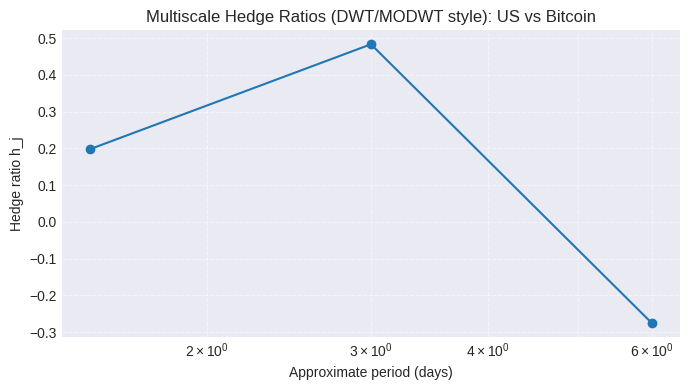


========== Pair: US vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -0.910
  Level 2 (~2–4 days): h_j ≈ -0.729
  Level 3 (~4–8 days): h_j ≈ 0.244

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.729
  Band 4–8 days (levels [3]): h_band ≈ 0.244
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


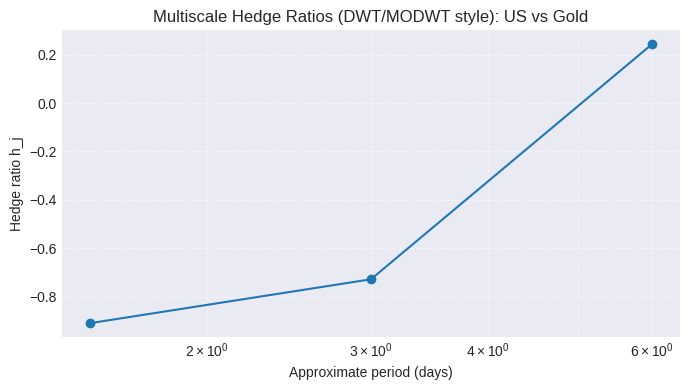


========== Pair: US vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.360
  Level 2 (~2–4 days): h_j ≈ -0.116
  Level 3 (~4–8 days): h_j ≈ -0.083

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.116
  Band 4–8 days (levels [3]): h_band ≈ -0.083
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


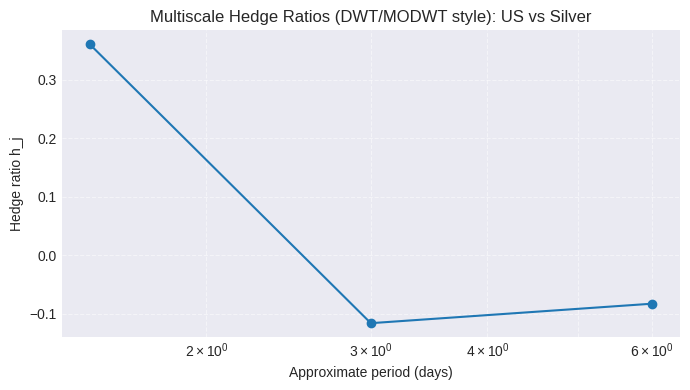


========== Pair: US vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.742
  Level 2 (~2–4 days): h_j ≈ -0.368
  Level 3 (~4–8 days): h_j ≈ -0.178

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.368
  Band 4–8 days (levels [3]): h_band ≈ -0.178
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


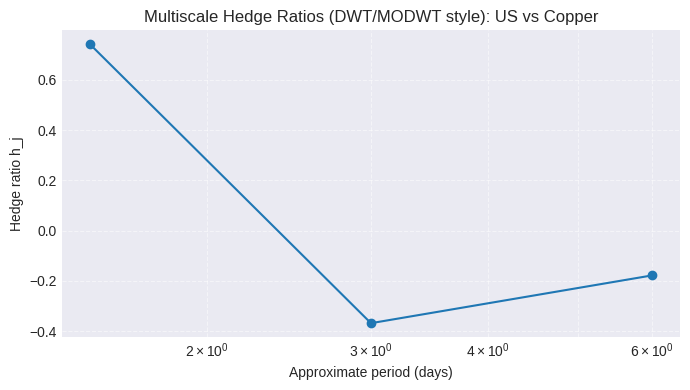


========== Pair: UK vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.198
  Level 2 (~2–4 days): h_j ≈ 0.483
  Level 3 (~4–8 days): h_j ≈ -0.276

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.483
  Band 4–8 days (levels [3]): h_band ≈ -0.276
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


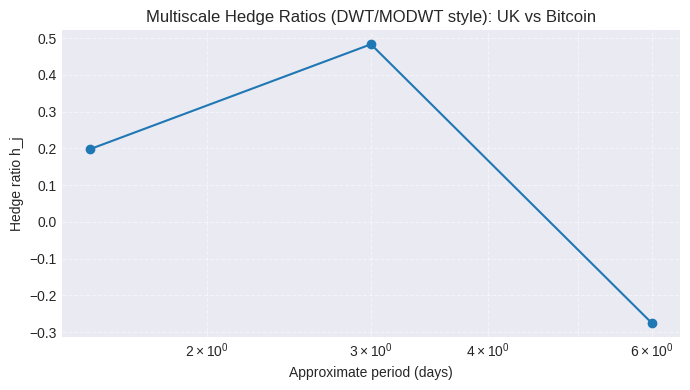


========== Pair: UK vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -0.910
  Level 2 (~2–4 days): h_j ≈ -0.729
  Level 3 (~4–8 days): h_j ≈ 0.244

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.729
  Band 4–8 days (levels [3]): h_band ≈ 0.244
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


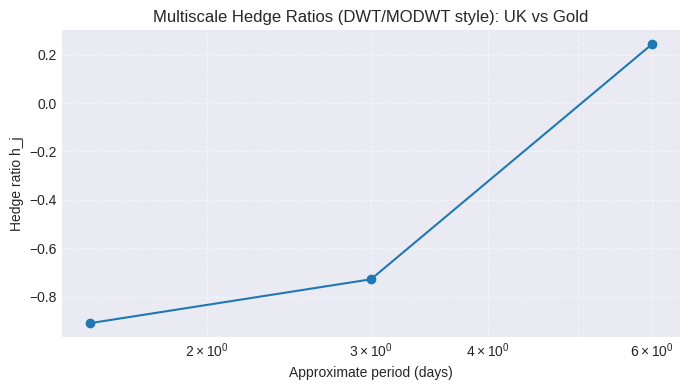


========== Pair: UK vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.360
  Level 2 (~2–4 days): h_j ≈ -0.116
  Level 3 (~4–8 days): h_j ≈ -0.083

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.116
  Band 4–8 days (levels [3]): h_band ≈ -0.083
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


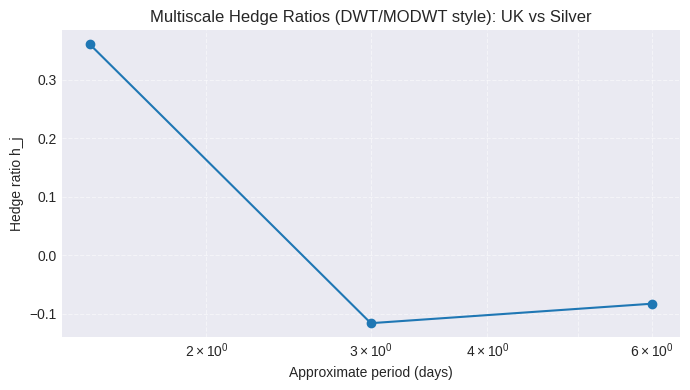


========== Pair: UK vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.742
  Level 2 (~2–4 days): h_j ≈ -0.368
  Level 3 (~4–8 days): h_j ≈ -0.178

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.368
  Band 4–8 days (levels [3]): h_band ≈ -0.178
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


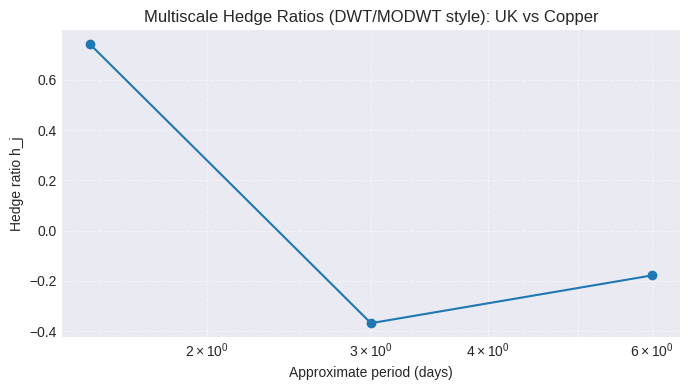


========== Pair: Germany vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.351
  Level 2 (~2–4 days): h_j ≈ 0.798
  Level 3 (~4–8 days): h_j ≈ 0.227

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.798
  Band 4–8 days (levels [3]): h_band ≈ 0.227
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


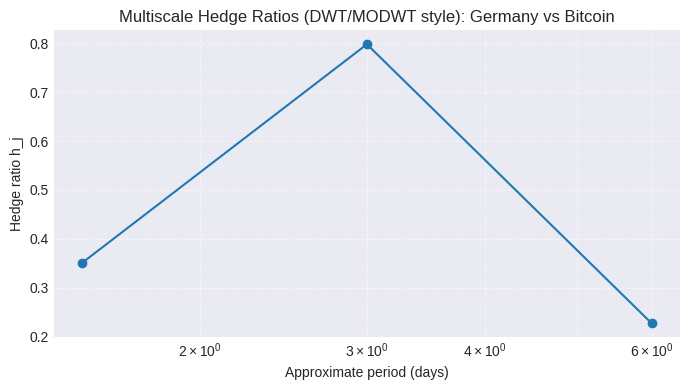


========== Pair: Germany vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -3.958
  Level 2 (~2–4 days): h_j ≈ -1.530
  Level 3 (~4–8 days): h_j ≈ 2.550

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -1.530
  Band 4–8 days (levels [3]): h_band ≈ 2.550
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


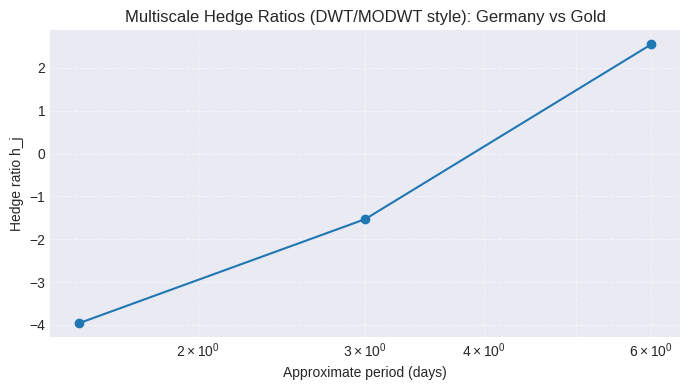


========== Pair: Germany vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -1.402
  Level 2 (~2–4 days): h_j ≈ -0.821
  Level 3 (~4–8 days): h_j ≈ 0.308

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.821
  Band 4–8 days (levels [3]): h_band ≈ 0.308
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


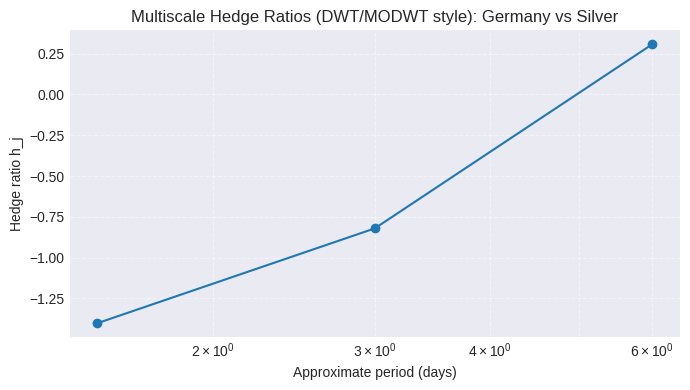


========== Pair: Germany vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.254
  Level 2 (~2–4 days): h_j ≈ 0.610
  Level 3 (~4–8 days): h_j ≈ 0.664

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.610
  Band 4–8 days (levels [3]): h_band ≈ 0.664
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


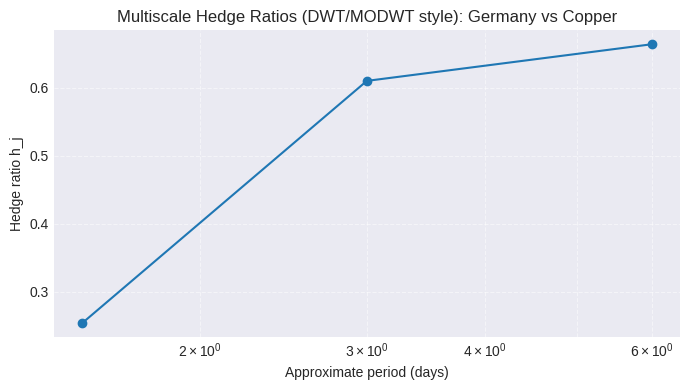


========== Pair: France vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.014
  Level 2 (~2–4 days): h_j ≈ 0.197
  Level 3 (~4–8 days): h_j ≈ -0.293

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.197
  Band 4–8 days (levels [3]): h_band ≈ -0.293
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


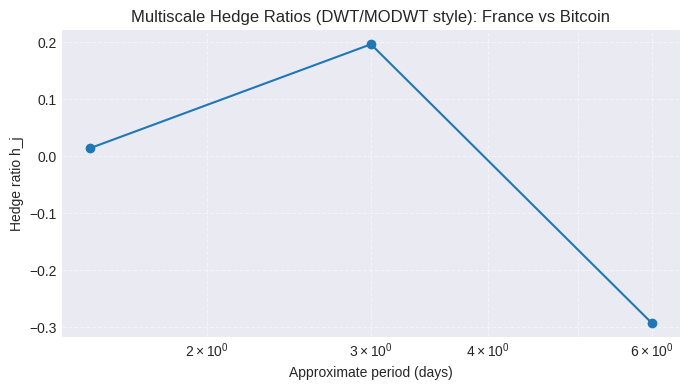


========== Pair: France vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.492
  Level 2 (~2–4 days): h_j ≈ -0.028
  Level 3 (~4–8 days): h_j ≈ 0.327

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.028
  Band 4–8 days (levels [3]): h_band ≈ 0.327
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


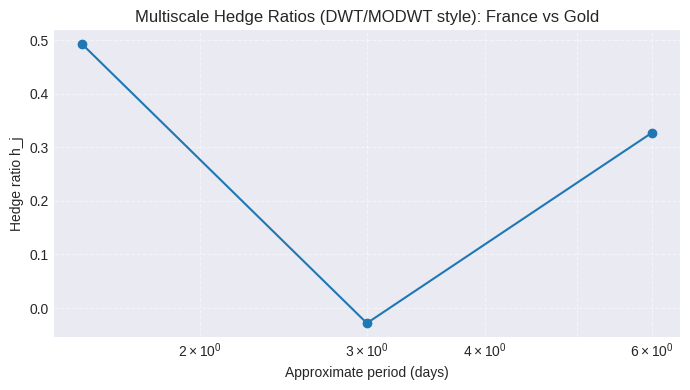


========== Pair: France vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.069
  Level 2 (~2–4 days): h_j ≈ -0.141
  Level 3 (~4–8 days): h_j ≈ -0.261

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.141
  Band 4–8 days (levels [3]): h_band ≈ -0.261
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


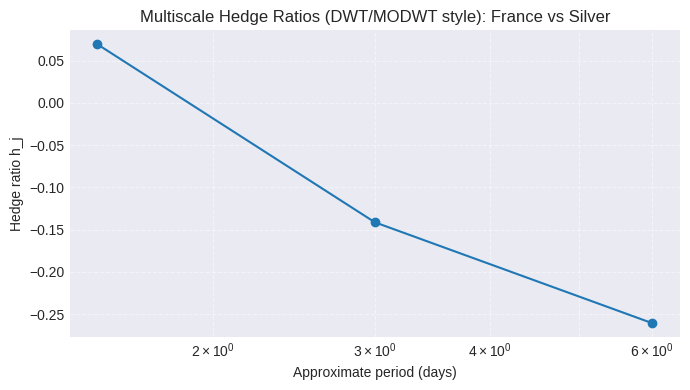


========== Pair: France vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -0.585
  Level 2 (~2–4 days): h_j ≈ 0.232
  Level 3 (~4–8 days): h_j ≈ -0.001

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.232
  Band 4–8 days (levels [3]): h_band ≈ -0.001
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


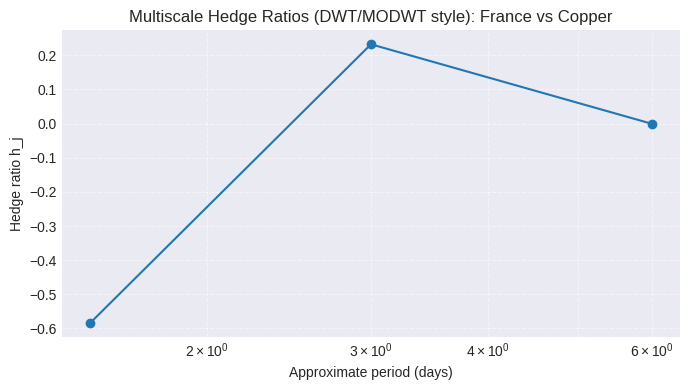


========== Pair: Japan vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -1.244
  Level 2 (~2–4 days): h_j ≈ 0.152
  Level 3 (~4–8 days): h_j ≈ -0.209

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.152
  Band 4–8 days (levels [3]): h_band ≈ -0.209
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


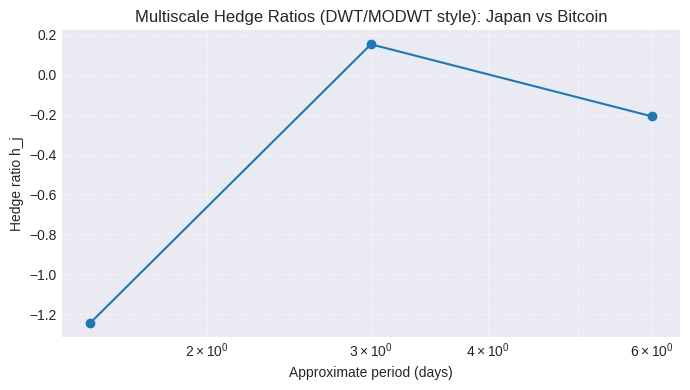


========== Pair: Japan vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 2.402
  Level 2 (~2–4 days): h_j ≈ 0.138
  Level 3 (~4–8 days): h_j ≈ 0.756

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.138
  Band 4–8 days (levels [3]): h_band ≈ 0.756
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


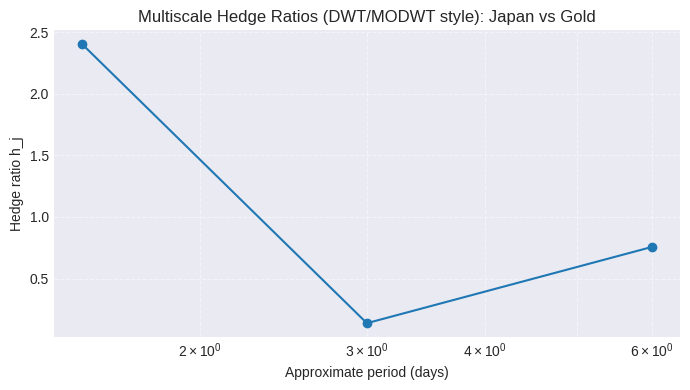


========== Pair: Japan vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.140
  Level 2 (~2–4 days): h_j ≈ 0.586
  Level 3 (~4–8 days): h_j ≈ -0.560

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.586
  Band 4–8 days (levels [3]): h_band ≈ -0.560
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


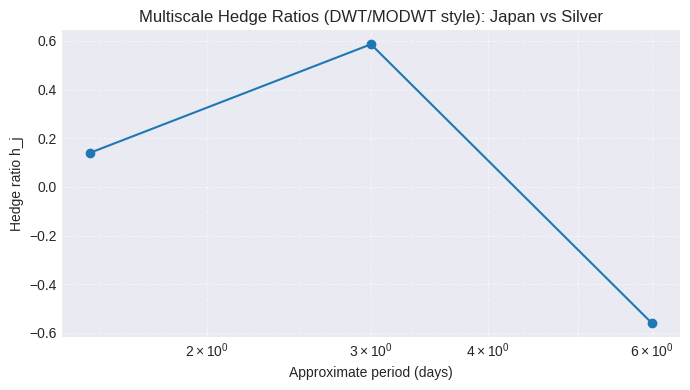


========== Pair: Japan vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -1.810
  Level 2 (~2–4 days): h_j ≈ -0.070
  Level 3 (~4–8 days): h_j ≈ -0.360

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.070
  Band 4–8 days (levels [3]): h_band ≈ -0.360
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


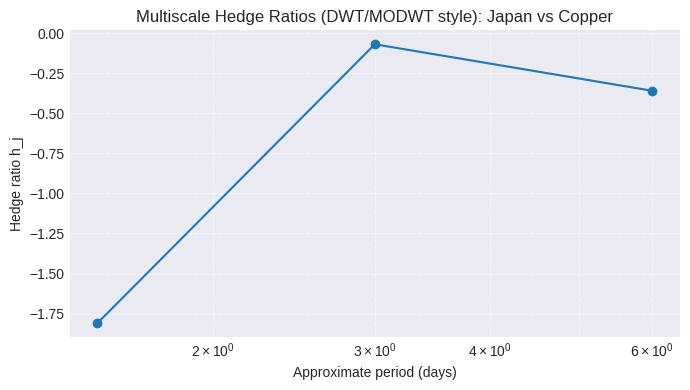


========== Pair: Brazil vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -0.945
  Level 2 (~2–4 days): h_j ≈ 0.005
  Level 3 (~4–8 days): h_j ≈ -0.040

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.005
  Band 4–8 days (levels [3]): h_band ≈ -0.040
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


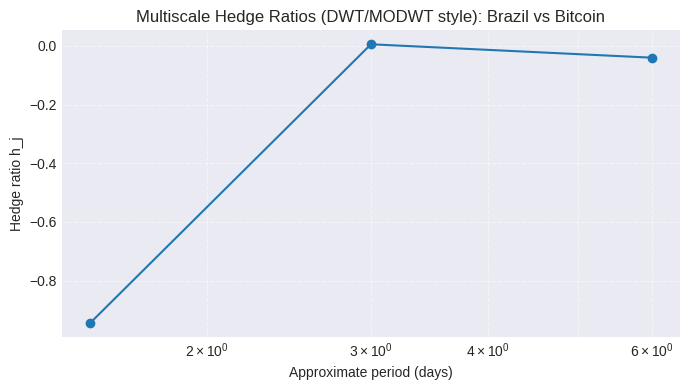


========== Pair: Brazil vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 2.282
  Level 2 (~2–4 days): h_j ≈ -1.972
  Level 3 (~4–8 days): h_j ≈ 0.218

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -1.972
  Band 4–8 days (levels [3]): h_band ≈ 0.218
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


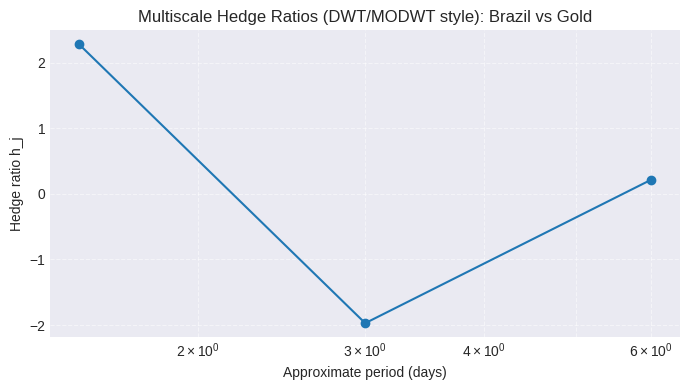


========== Pair: Brazil vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -0.010
  Level 2 (~2–4 days): h_j ≈ -0.974
  Level 3 (~4–8 days): h_j ≈ -0.541

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.974
  Band 4–8 days (levels [3]): h_band ≈ -0.541
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


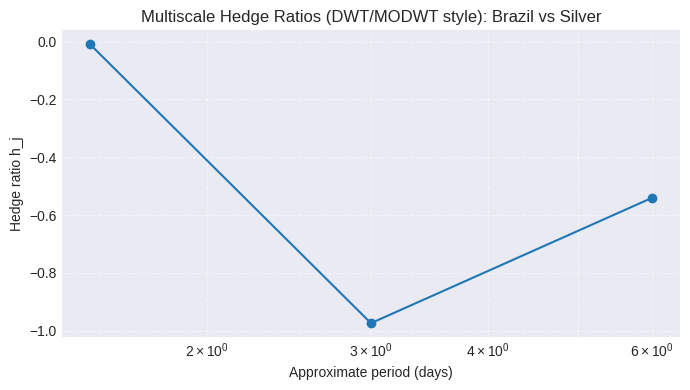


========== Pair: Brazil vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -2.894
  Level 2 (~2–4 days): h_j ≈ -1.368
  Level 3 (~4–8 days): h_j ≈ -0.476

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -1.368
  Band 4–8 days (levels [3]): h_band ≈ -0.476
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


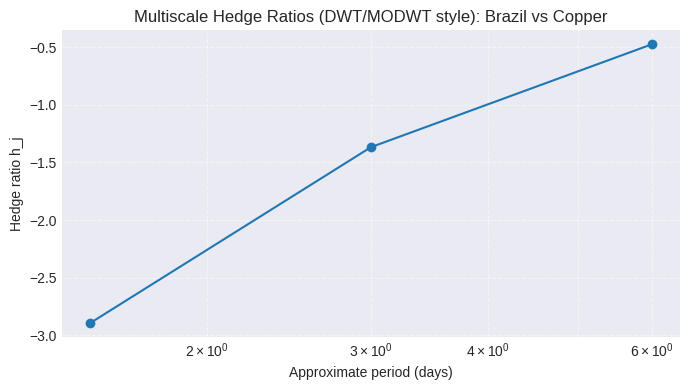


========== Pair: China vs Bitcoin ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -1.160
  Level 2 (~2–4 days): h_j ≈ 0.031
  Level 3 (~4–8 days): h_j ≈ -0.190

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ 0.031
  Band 4–8 days (levels [3]): h_band ≈ -0.190
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


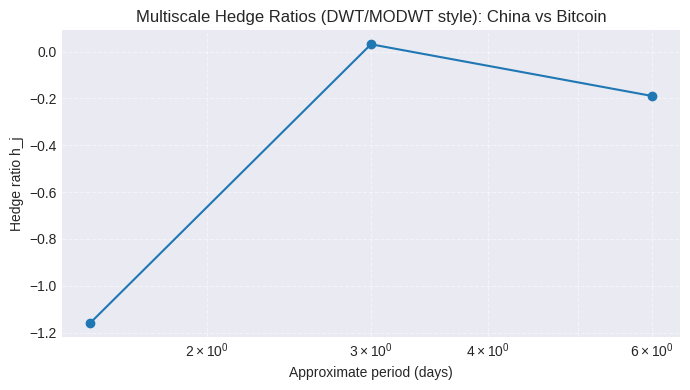


========== Pair: China vs Gold ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 2.475
  Level 2 (~2–4 days): h_j ≈ -0.214
  Level 3 (~4–8 days): h_j ≈ 1.898

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.214
  Band 4–8 days (levels [3]): h_band ≈ 1.898
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


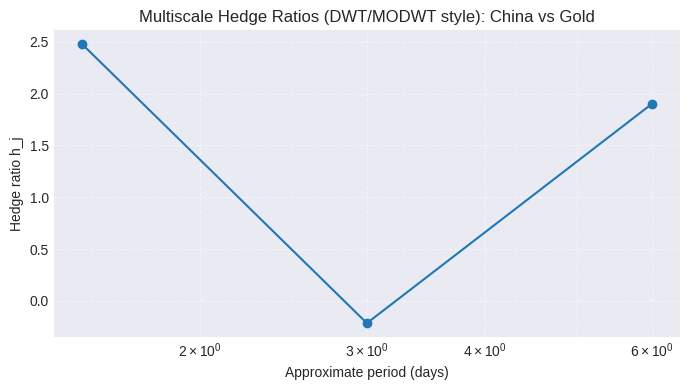


========== Pair: China vs Silver ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ 0.039
  Level 2 (~2–4 days): h_j ≈ -0.346
  Level 3 (~4–8 days): h_j ≈ -1.022

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -0.346
  Band 4–8 days (levels [3]): h_band ≈ -1.022
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


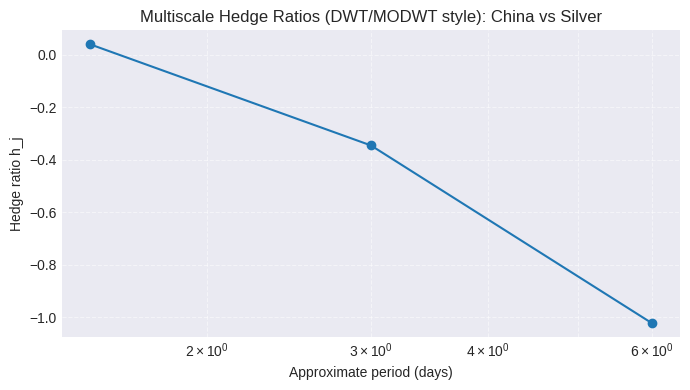


========== Pair: China vs Copper ==========
Multiscale hedge ratios by level:
  Level 1 (~1–2 days): h_j ≈ -2.097
  Level 2 (~2–4 days): h_j ≈ -1.140
  Level 3 (~4–8 days): h_j ≈ -0.305

Frequency-band hedge ratios (averaged across levels/time):
  Band 2–4 days (levels [2]): h_band ≈ -1.140
  Band 4–8 days (levels [3]): h_band ≈ -0.305
  Band 8–16 days (levels []): h_band ≈ nan
  Band 16–32 days (levels []): h_band ≈ nan
  Band 32–64 days (levels []): h_band ≈ nan
  Band 64–128 days (levels []): h_band ≈ nan


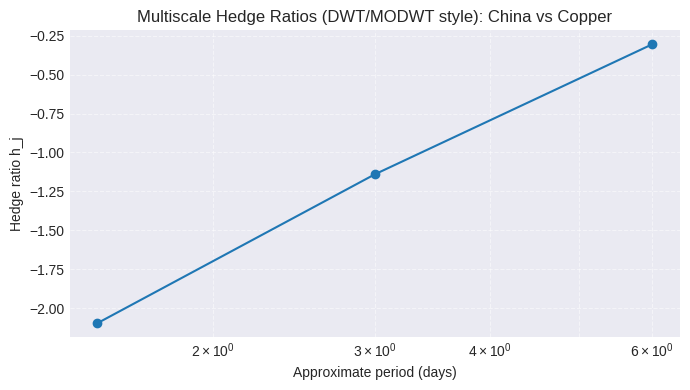

In [6]:
# ===============================================================
# CELL 6: Compute multiscale hedge ratios and frequency-band hedge ratios
# ===============================================================
results_band = []

for hedge, btc in PAIR_LIST:
    print(f"\n========== Pair: {hedge} vs {btc} ==========")
    x_ret = df_ret[hedge]
    y_ret = df_ret[btc]

    # Multiscale hedge ratios h_j per level
    h_levels, max_level = multiscale_hedge_ratios(x_ret, y_ret, wavelet="db4", level=None)

    print("Multiscale hedge ratios by level:")
    for j, h_j in h_levels.items():
        low_j, high_j = level_to_period_range(j, dt=dt)
        print(f"  Level {j} (~{low_j:.0f}–{high_j:.0f} days): h_j ≈ {h_j:.3f}")

    # Map levels to target bands and get band-averaged hedge ratios
    band_levels = assign_levels_to_bands(max_level, dt=dt)
    band_h = band_averaged_hedge_ratios(h_levels, band_levels)

    print("\nFrequency-band hedge ratios (averaged across levels/time):")
    for b, h_b in band_h.items():
        print(f"  Band {b[0]}–{b[1]} days (levels {band_levels[b]}): h_band ≈ {h_b:.3f}")

    results_band.append(
        {
            "pair": f"{hedge} vs {btc}",
            "h_levels": h_levels,
            "band_levels": band_levels,
            "band_h": band_h,
        }
    )

    # Plot h_j vs approximate scale
    levels_sorted = sorted(h_levels.keys())
    periods_mid = [0.5 * sum(level_to_period_range(j, dt=dt)) for j in levels_sorted]
    hs = [h_levels[j] for j in levels_sorted]

    plt.figure(figsize=(7, 4))
    plt.plot(periods_mid, hs, marker="o")
    plt.xscale("log")
    plt.xlabel("Approximate period (days)")
    plt.ylabel("Hedge ratio h_j")
    plt.title(f"Multiscale Hedge Ratios (DWT/MODWT style): {hedge} vs {btc}")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [7]:
# ===============================================================
# CELL 7: Construct a dynamic hedge ratio series from band-averaged h
# ===============================================================
"""
Here we approximate a 'dynamic' hedge ratio per band by:
- Using the multiscale decomposition to reconstruct band-specific components
  of returns, and
- Applying the band h_band as a constant weight per band, then summing bands.

Because pywt.wavedec returns finite-length coefficient vectors, this is an
approximate, scale-based dynamic hedge ratio (time-varying through scale
composition) rather than a fully local h(t,s). [web:23][web:31]
"""

def reconstruct_band_component(series, wavelet, level, levels_in_band):
    """
    Reconstruct time series component for subset of levels (details only).
    """
    # full decomposition
    y = series.values
    max_level = pywt.dwt_max_level(len(y), pywt.Wavelet(wavelet).dec_len)
    level = min(level, max_level)
    coeffs = pywt.wavedec(y, wavelet, level=level, mode="periodization")

    # zero-out all detail levels not in levels_in_band, keep approx
    new_coeffs = [coeffs[0].copy()]
    for j in range(1, level + 1):
        if j in levels_in_band:
            new_coeffs.append(coeffs[j].copy())
        else:
            new_coeffs.append(np.zeros_like(coeffs[j]))

    y_band = pywt.waverec(new_coeffs, wavelet, mode="periodization")
    # align length
    y_band = y_band[:len(series)]
    return pd.Series(y_band, index=series.index)


dynamic_results = []

for res in results_band:
    pair = res["pair"]
    hedge, btc = pair.split(" vs ")
    x_ret = df_ret[hedge]
    y_ret = df_ret[btc]

    h_levels = res["h_levels"]
    band_levels = res["band_levels"]
    band_h = res["band_h"]

    # choose wavelet and level from previous computation
    wavelet = "db4"
    max_level = max(h_levels.keys())

    # For each band, reconstruct band component of returns and apply h_band
    # r_H_t = sum_b [ h_b * r_Hedge_band_b_t ]
    # dynamic hedge ratio effective in time domain via band composition.
    r_hedge_total = pd.Series(0.0, index=x_ret.index)

    for b, levels_in_band in band_levels.items():
        if not levels_in_band:
            continue
        h_b = band_h[b]
        if np.isnan(h_b):
            continue

        x_band = reconstruct_band_component(x_ret, wavelet, max_level, levels_in_band)
        r_hedge_total += h_b * x_band

    # hedged portfolio return = BTC minus band-hedge component
    y_ret_aligned, r_hedge_aligned = y_ret.align(r_hedge_total, join="inner")
    r_hedged = y_ret_aligned - r_hedge_aligned

    var_unhedged = np.var(y_ret_aligned)
    var_hedged = np.var(r_hedged)
    vr = 1.0 - var_hedged / (var_unhedged + 1e-12)

    print(f"\nDynamic (band-composed) hedge effectiveness for {pair}:")
    print(f"  Variance (unhedged BTC): {var_unhedged:.4e}")
    print(f"  Variance (hedged): {var_hedged:.4e}")
    print(f"  Variance reduction: {vr * 100:.2f}%")

    # Plot cumulative returns
    cum_unhedged = y_ret_aligned.cumsum()
    cum_hedged = r_hedged.cumsum()
    plt.figure(figsize=(9, 4))
    plt.plot(cum_unhedged.index, cum_unhedged.values, label="Unhedged BTC")
    plt.plot(cum_hedged.index, cum_hedged.values, label="Hedged (band-composed)")
    plt.title(f"Cumulative Returns (DWT/MODWT band hedge): {pair}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative log return")
    plt.legend()
    plt.tight_layout()
    plt.show()

    dynamic_results.append(
        {
            "pair": pair,
            "variance_reduction": vr,
            "band_h": band_h,
        }
    )

Output hidden; open in https://colab.research.google.com to view.

In [8]:
# ===============================================================
# CELL 8: Textual summary of multiscale / band hedge ratios
# ===============================================================
print("\n\n================ DWT/MODWT MULTISCALE HEDGE SUMMARY ================\n")

for res in results_band:
    pair = res["pair"]
    band_h = res["band_h"]
    print(f"\nPair: {pair}")
    for b, h_b in band_h.items():
        print(f"  Band {b[0]}–{b[1]} days: h_band ≈ {h_b:.3f}")

print("\nInterpretation notes (DWT/MODWT only):")
print("- Levels correspond to approximate horizons [2^(j-1), 2^j] days;")
print("  band hedge ratios aggregate these into economically relevant bands such as 2–4, 4–8, … days. [web:23][web:46]")
print("- Increasing hedge ratios at longer scales often indicate stronger long-horizon linkage and hedging potential. [web:46][web:55]")
print("- Band-composed hedged portfolios that achieve substantial variance reduction suggest effective frequency-specific hedging.")



================ DWT/MODWT MULTISCALE HEDGE SUMMARY ================


Pair: US vs Bitcoin
  Band 2–4 days: h_band ≈ 0.483
  Band 4–8 days: h_band ≈ -0.276
  Band 8–16 days: h_band ≈ nan
  Band 16–32 days: h_band ≈ nan
  Band 32–64 days: h_band ≈ nan
  Band 64–128 days: h_band ≈ nan

Pair: US vs Gold
  Band 2–4 days: h_band ≈ -0.729
  Band 4–8 days: h_band ≈ 0.244
  Band 8–16 days: h_band ≈ nan
  Band 16–32 days: h_band ≈ nan
  Band 32–64 days: h_band ≈ nan
  Band 64–128 days: h_band ≈ nan

Pair: US vs Silver
  Band 2–4 days: h_band ≈ -0.116
  Band 4–8 days: h_band ≈ -0.083
  Band 8–16 days: h_band ≈ nan
  Band 16–32 days: h_band ≈ nan
  Band 32–64 days: h_band ≈ nan
  Band 64–128 days: h_band ≈ nan

Pair: US vs Copper
  Band 2–4 days: h_band ≈ -0.368
  Band 4–8 days: h_band ≈ -0.178
  Band 8–16 days: h_band ≈ nan
  Band 16–32 days: h_band ≈ nan
  Band 32–64 days: h_band ≈ nan
  Band 64–128 days: h_band ≈ nan

Pair: UK vs Bitcoin
  Band 2–4 days: h_band ≈ 0.483
  Band 4–8 days: h_ban